# Libraries

Apart from some common libraries and PyTorch, there are a few things needed from helper and util libraries. These libraries are stored in the folder `./shared/`:
- `utils`
- `engine`

`utils` and `engine` are needed to later train the model.

In [1]:
import pandas as pd
import numpy as np
import sys
import os

sys.path.append('./shared/')
import utils
import engine

import tqdm
import PIL
from sklearn.model_selection import train_test_split
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torchvision
from torch.utils.tensorboard import SummaryWriter
from torchvision.io import decode_image
from torchvision.ops.boxes import masks_to_boxes
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
from torchvision.models.detection.mask_rcnn import MaskRCNN
from torchvision.transforms import v2 as T
from torchvision.models.detection.transform import GeneralizedRCNNTransform
from torchvision.models.feature_extraction import create_feature_extractor
from torchvision.models.detection.backbone_utils import LastLevelMaxPool
from torchvision.ops.feature_pyramid_network import FeaturePyramidNetwork
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import timm

/Users/hayley/opt/anaconda3/envs/zoobot-segmentation/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Settings and global vars

In [2]:
# Pathes to data files, training and other imaging data.
# Change accordingly to suit your needs.
DATA_PATH = './data/'
PREDICTIONS_FILE_PATH = './predictions/'
MODEL_OUTPUT_PATH = './model/'
IMAGE_DATA_PATH = DATA_PATH + 'train_images/'

In [3]:
# Check if GPUs or MPS is available
# fallback to CPU otherwise
if torch.cuda.is_available():
    TORCH_DEVICE = torch.device('cuda')
    GPU_COUNT = torch.cuda.device_count()
    print('Device: {}, Number of GPUs: {}'.format(TORCH_DEVICE, GPU_COUNT))
elif torch.backends.mps.is_available():
    TORCH_DEVICE = torch.device('mps')
    print('Device: {}'.format(TORCH_DEVICE))
else:
    TORCH_DEVICE = torch.device('cpu')
    print('Device: {}'.format(TORCH_DEVICE))

Device: cpu


In [4]:
# force cpu as mps is still causing issues
TORCH_DEVICE = torch.device('cpu')

# Training data

The image segmentation model should learn to identify and mask spiral arms and/or bars in galaxies. Together with an additional default class for the background, the training dataset has class labels encoded like below:

In [5]:
class_labels = {
    'background': 0,
    'spiral_arm': 1,
    'bar': 2,
}

Keep in mind, that for object detection and image segmentation models we always need an additional label for the background. The default label is `0` for that and we keep it this throughout. The background label is not assigned to a specific mask we need for training, so there will be no specific entry for the background in all training data.

For this demonstration I have included a set of training data from [GalaxyZoo: 3D](https://www.zooniverse.org/projects/klmasters/galaxy-zoo-3d). There are 1,445 galaxies with masks outlining either the spiral arms, bars or both, depending on what was marked by the volunteers. The masks have been created from the set of volunteers' answers by simpy applying a pixel threshold $\geq 50$. This approach might be too simple and not completely suitable for other scientific needs.

We also need the labels and bounding boxes for each mask. These are stored in a Pandas dataframe using Parquet and can be loaded using the code below (note, that it might be necessary to install pyarrow):

In [6]:
df_training_data = pd.read_parquet(DATA_PATH + 'mask_labels.gzip', engine='pyarrow')

The dataframe has the following columns where each column represents a single mask, either spiral arm or bar, indicated by the label:
1. `index`
2. `mask_id` : ID for the mask of a single galaxy, ususally 1 for the spiral arm and 2 for the bar as in most cases there are two masks for each galaxy
3. `labels` : the label-id of the mask (see class_labels above)
4. `train_group` : if this mask is used for training or validation
5. `object_id` : unique ID for the galaxy, also functions as file name for the galaxy image and the mask-file
6. `bbox_xmax`, `bbox_xmin`, `bbox_ymax` and `bbox_ymin` : x/y-coordinates of the bounding box around the mask in pixels

This demonstration requires this structure for the training data with the exact same names. If new training data is generated, there is either a reformating of the data needed or you have to adjust the Python code here in this Notebook and probably also in the helper libraries.

Let's have a quick look at the table with the mask labels and bounding boxes:

In [7]:
df_training_data

,mask_id,bbox_xmax,bbox_xmin,bbox_ymax,bbox_ymin,labels,object_id,train_group
0,1,276,141,279,148,1,3743953484,validation
1,2,253,178,231,192,2,3743953484,validation
2,1,284,123,245,173,1,3353371517,validation
3,2,230,194,221,205,2,3353371517,validation
4,1,276,154,264,168,1,346827436,validation
...,...,...,...,...,...,...,...,...
2145,2,220,201,226,199,2,449763538,training
2146,1,250,174,256,163,1,4228211112,training
2147,2,218,204,226,201,2,4228211112,training
2148,1,298,126,316,107,1,447972746,validation


We can also simply plot the image and overlay the masks:

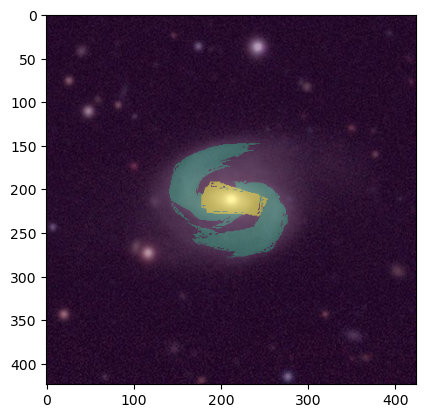

In [8]:
objid = 3743953484
img = matplotlib.image.imread(IMAGE_DATA_PATH + 'mask_train_images_pngs/' + str(objid) + '.png')
mask = matplotlib.image.imread(IMAGE_DATA_PATH + 'mask_train_images_masks/' + str(objid) + '_mask.png')
plt.imshow(img)
plt.imshow(mask, alpha=0.4)

The masks are stored as an image file (PNG here) with the same extent as the corresponding galaxy image. The extent or area of different masks are stored with pixel values that corresponds to their class label, here `1` for spiral arms and `2` for bars. This is important as this connects the mask image to the dataframe with bounding box and label information. The background has always a pixel value of `0` and does not need any special consideration. It needs to be `0` (or the lowest ID for a class label) as our dataset class will separate all the different masks, sorting them by ID and cut off the background class.

A simple check shows you the count of pixel values in our example:

In [9]:
mask_png = PIL.Image.open(IMAGE_DATA_PATH + 'mask_train_images_masks/' + str(objid) + '_mask.png')
mask_array = np.array(mask_png.getdata())

np.unique(mask_array, return_counts=True)

(array([0, 1, 2]), array([170288,   7488,   2000]))

The training dataset needs to be split into a training and validation set (if needed, you could also add a test set). This has been done for our demonstration dataset already and the groups are indicated by the field `train_group` in the dataframe.

Now, we need to prepare the datasets (images, masks and bounding boxes) to be used for object detection model. We need a modified [dataset class](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset), a [data loader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) and a set of augmentation functions for the training data.

The dataset class below is initialised with a dataframe containing IDs, a path to the main directory with the training images and masks and a set of image/mask transformations or augmentations. The `object_id` is used as the filename for the galaxy image and also the masks, but masks will get added the suffix `_mask`. Galaxy images and mask images are stored in different subdirectories, `mask_train_images_pngs` and `mask_train_images_masks`, respectively. These things are all hardcoded for this simple demonstration. Feel free to adjust to your own needs!

Mask R-CNN also requires a bounding box around the segment mask, which is stored in our dataframe with the training data and used to initialise the dataset object.

In [10]:
class MaskGalaxyDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, image_dir, transforms=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transforms = transforms
        self.image_ids = dataframe['object_id'].unique()

    def __getitem__(self, idx):
        # load images and masks
        image_id = self.image_ids[idx]
        records = self.df[self.df['object_id'] == image_id]

        img_path = os.path.join(self.image_dir, 'mask_train_images_pngs', str(image_id) + '.png')
        mask_path = os.path.join(self.image_dir, 'mask_train_images_masks', str(image_id) + '_mask.png')
        img = decode_image(img_path)
        mask = decode_image(mask_path)
        img = F.convert_image_dtype(img, dtype=torch.float)
        mask = F.convert_image_dtype(mask, dtype=torch.float)

        # instances are encoded as different colors
        obj_ids = torch.unique(mask)
        # first id is the background, so remove it
        obj_ids = obj_ids[1:]
        num_objs = len(obj_ids)

        # split the color-encoded mask into a set
        # of binary masks
        masks = (mask == obj_ids[:, None, None]).to(dtype=torch.uint8)

        # get bounding box coordinates for each mask and handle empty bounding boxes
        # boxes = masks_to_boxes(masks)
        boxes = records[['bbox_xmin', 'bbox_ymin', 'bbox_xmax', 'bbox_ymax']].values
        if np.isnan(boxes).all():
            boxes = torch.zeros((0, 4), dtype=torch.float32)
        else:
            boxes = torch.as_tensor(boxes,dtype=torch.float32)

        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])

        # there is only one class
        # labels = torch.ones((num_objs,), dtype=torch.int64)
        labels_list = records[['labels']].values
        labels = torch.as_tensor(labels_list, dtype=torch.int64)
        labels = torch.squeeze(labels, 1)

        # suppose all instances are not crowd
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # Wrap sample and targets into torchvision tv_tensors:
        img = tv_tensors.Image(img)

        target = {}
        target['boxes'] = tv_tensors.BoundingBoxes(boxes, format='XYXY', canvas_size=F.get_size(img))
        target['masks'] = tv_tensors.Mask(masks)
        target['labels'] = labels
        target['image_id'] = torch.tensor([image_id])
        target['area'] = area
        target['iscrowd'] = iscrowd

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.image_ids)

The dataset classes can be initialised with a list of image augmentation functions. In our cases we want randomly flipped images for the training run. These image transformation or augmentation functions are only applied to the train data set, not the validation. Some general transforms are applied to both, train and validation, and are mainly to ensure that they are a proper tensor with the right data type.

There are more transformation or augmentation functions available from `torchvision.transforms`, and these can be added here if needed.

In [11]:
def get_transform(train):
    transforms = []

    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
        transforms.append(T.RandomVerticalFlip(0.5))

    transforms.append(T.PILToTensor())
    transforms.append(T.ConvertImageDtype(torch.float))

    return T.Compose(transforms)

Then we define the data loader for which we use our dataframe with the object-IDs and labels, the directory with the images and our transform/augmentation functions from above.

The function below returns a dictionary containing a dataloader for the train and validation set.

In [12]:
def get_dataloader_dict(train_df, val_df, image_dir, batch_size):
    image_datasets = {}

    image_datasets['train'] = MaskGalaxyDataset(
        dataframe=train_df,
        image_dir=image_dir,
        transforms=get_transform(train=True)
    )
    image_datasets['val'] = MaskGalaxyDataset(
        dataframe=val_df,
        image_dir=image_dir,
        transforms=get_transform(train=False)
    )
    
    return {x: torch.utils.data.DataLoader(
        image_datasets[x], 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        collate_fn=utils.collate_fn
    ) for x in ['train', 'val']}

Now, let's test if the data loader is working, showing only the bounding boxes.

In [13]:
# Test dataloader HSC/CLAUDS
dataloader_dict = get_dataloader_dict(
    train_df=df_training_data[(df_training_data['train_group']=='training')],
    val_df=df_training_data[(df_training_data['train_group']=='validation')],
    image_dir=IMAGE_DATA_PATH,
    batch_size=1
)

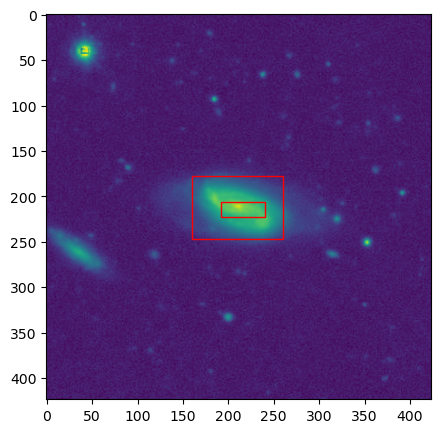

In [14]:
images, targets = next(iter(dataloader_dict['train']))
images = list(img.to(TORCH_DEVICE) for img in images)
targets = [{k: v.to(TORCH_DEVICE) for k, v in t.items()} for t in targets]

for i in range(1):
    boxes = targets[i]['boxes'].cpu().numpy().astype(np.int32)
    sample = PIL.Image.fromarray(( images[i][0].cpu().numpy() * 255)).convert('L')
    plt.figure(figsize=(5, 5))
    
    for box in boxes:
        rect_hsc = matplotlib.patches.Rectangle(
            (box[0], box[1]),
            box[2]-box[0], box[3]-box[1],
            facecolor='None', 
            edgecolor='r',
            ls='-',
            linewidth=1,
        )
        plt.gca().add_patch(rect_hsc)

    plt.imshow(sample)
    # plt.axis('off')

# Defining the model

Similar to the Faster R-CNN object detection model, the Mask R-CNN will be using an architecture with ResNet50 feature layers or blocks as its classification backbone. It should be possible to take any CNN as a backbone, e.g. EfficientNet, and it would be worth exploring the performance of different CNN-architectures in combination with Mask R-CNN. Here is a link to the original [paper](https://arxiv.org/abs/1703.06870), if you want to know more about Mask R-CNN

The principle architecture of ResNet50, ResNet100 or other variation is shown in this image:

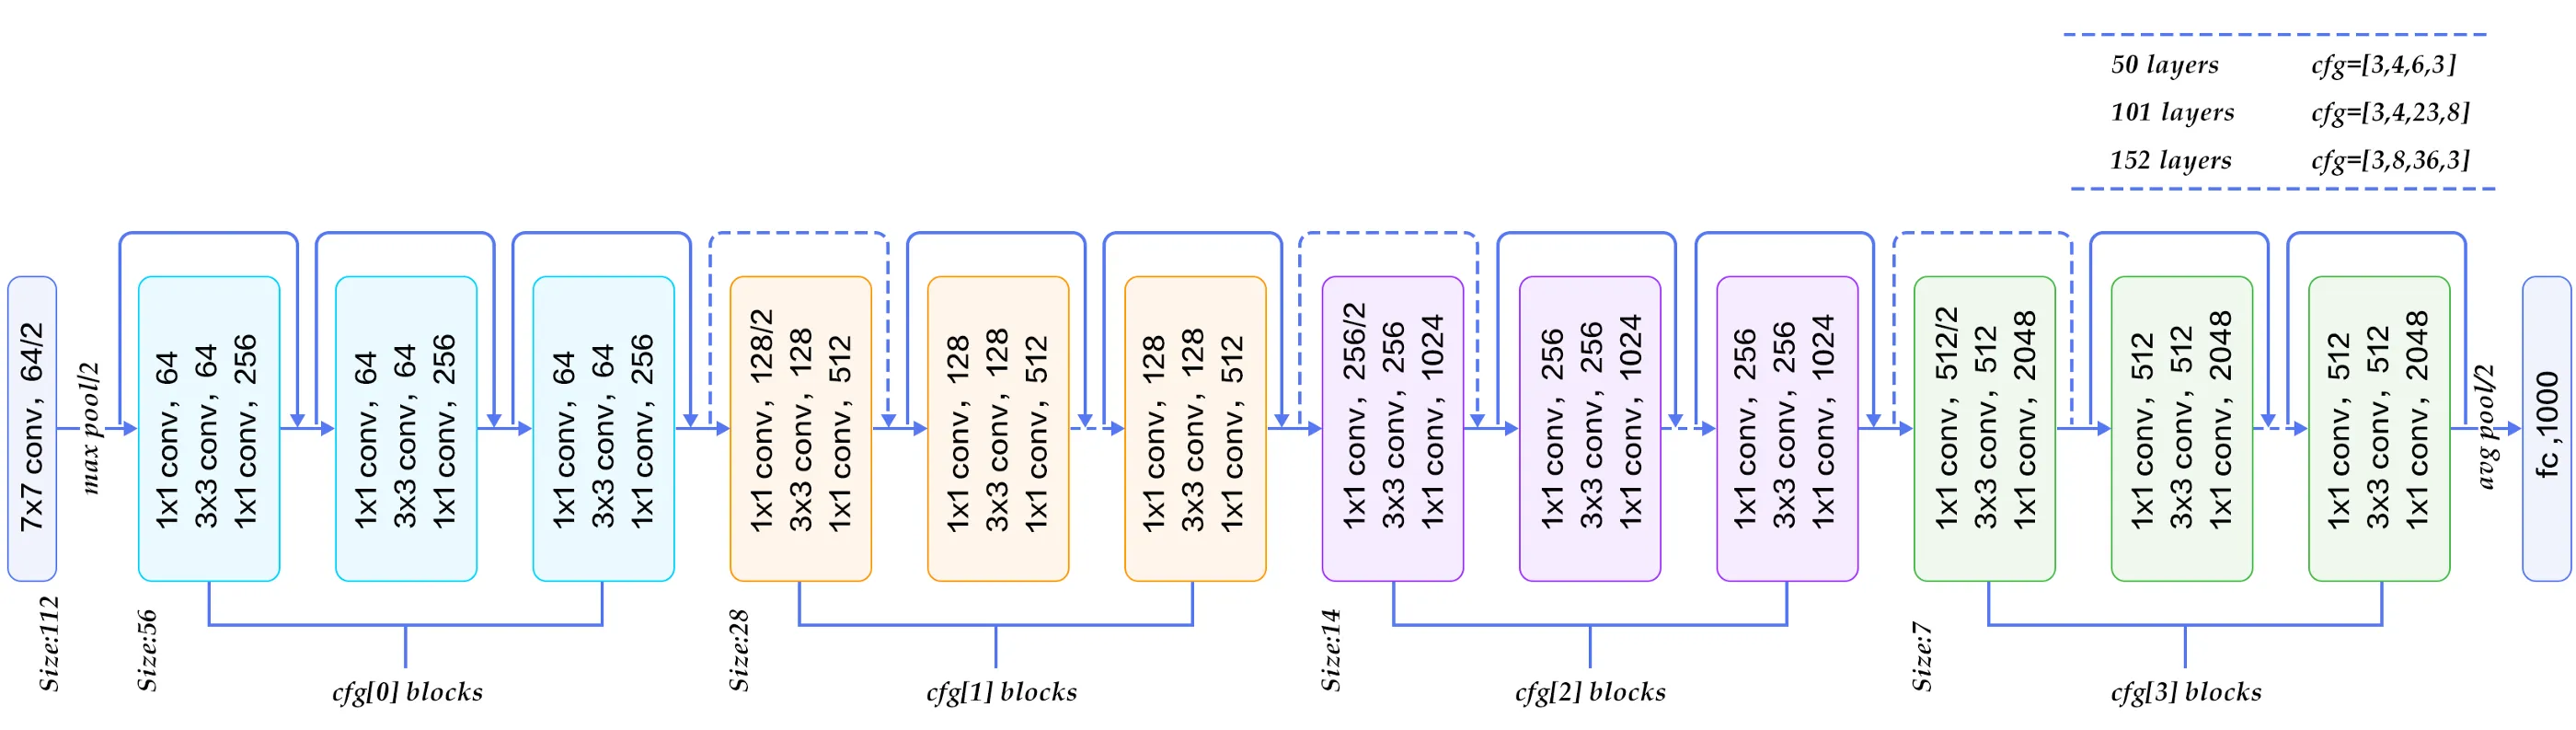

For the Mask R-CNN model we're simply cutting out the four convolutional blocks with their weights and add a FPN at the end. More importantly is what pre-trained ResNet50-CNN we're choosing for our object detection task. The model classes below can be initialised either with
1. random weights (plain, untrained ResNet)
2. terrestrial pretraining (e.g. ImageNet)
3. astronomical pretraining (Zoobot)

The terrestrial weights are coming with the Pytorch library whereas Zoobot is directly loaded from the HuggingFace repo (so you need `timm` installed and loaded).

So far, this is the same process as for the Faster R-CNN model implementation by Pytorch. To change it into a Mask R-CNN model we're initialising the `MaskRCNN` class from `torchvision.models.detection.mask_rcnn` with our custom backbone.

Then, we define a function which actually initialises the model and add some more parameters (e.g. mean and standard deviation of all the pixel values in the images) and offers an option to unfreeze or freeze specific convolutional blocks of the feature extraction backbone. This option allows for different levels of fine-tuning, setting either the last, second to last, second, first block or even the first convolution layer free to be trained. For a simple transfer learning approach, all blocks would be set to be fixed and their weights freezed.

Very important for initialising the model is the number of classes the model should also try to identify. In our case we have two classes for clumps ('normal' and 'odd') and three classes for contaminations or non-clump objects, plus the required class for the background, giving us six classes in total.

Let's start with the model class for the classification backbone.

In [15]:
# Faster R-CNN with 6 channels
class Resnet50WithFPN(torch.nn.Module):
    def __init__(self, weights):
        super(Resnet50WithFPN, self).__init__()

        self.weights = weights

        if self.weights is not None:
            if self.weights == 'Zoobot':
                m = timm.create_model('hf_hub:mwalmsley/zoobot-encoder-resnet50', pretrained=True, num_classes=2)
            else:
                # e.g. weights='DEFAULT' or weights='IMAGENET1K_V1'
                m = torchvision.models.resnet50(weights=self.weights)
        else:
            m = torchvision.models.resnet50()

        # Extract 4 main layers (note: FRCNN needs this particular name mapping for return nodes)
        self.body = create_feature_extractor(
            m,
            return_nodes={f'layer{k}': str(v) for v, k in enumerate([1, 2, 3, 4])}
        )
        
        # Dry run to get number of channels for FPN
        inp = torch.randn(2, 3, 224, 224)
        # inp = inp.to(TORCH_DEVICE)
        
        with torch.no_grad():
            out = self.body(inp)
        in_channels_list = [o.shape[1] for o in out.values()]
        
        # Build FPN
        self.out_channels = 256
        self.fpn = FeaturePyramidNetwork(
            in_channels_list, out_channels=self.out_channels,
            extra_blocks=LastLevelMaxPool())

    def forward(self, x):
        x = self.body(x)
        x = self.fpn(x)
        return x

And here is an example of function which initalises the final model. 

As you can see, there is also an option to load custom pretrained weights through a saved checkpoint. Also, we redefine the transform layer to better fit our needs, especially the mean and std.dev. values for the image pixels used for normalising the images. The settings for `min_size` and `max_size` ensure, that images outside this range are rescaled to match the required input size.

In [16]:
def get_model(
        ckpt, 
        device,
        weights,
        num_classes, 
        trainable_layers, 
        image_mean, 
        image_std
    ):
    """
    Creates the model object for Faster R-CNN

    Args:
      ckpt (str) : path to checkpoint with custom pretrained weights
      device (torch.device or str) : torch device
      weights (str or None) : pretrained weights for the ResNet50 backbone, either 'Zoobot' for loading the Zoobot ResNet50 model
        from HuggingFace, a PyTorch weight set for ResNet50 'DEFAULT' or 'IMAGENET1K_V1', or None
        (see here for pretrained weights for ResNet50: https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html#torchvision.models.resnet50)
      num_classes (int) : number of classes the detector should output, must include a class for the background
      trainable_layers (int) : number of blocks of the classification backbone,
        counted from top, that should be made trainable
        e.g. 0 - all blocks fixed, 5 - all blocks and incl. 'backbone.body.conv1' trainable
      image_mean (list of floats) : mean of the pixel values for each image filter or channel
      image_std (list of floats) : standard deviation of the pixel values for each image filter or channel

    Returns:
      Mask R-CNN model
    """

    # Build the model
    model = MaskRCNN(Resnet50WithFPN(weights=weights), num_classes=num_classes)

    # load checkpoint, model_type 'Zoobot' or 'FRCNN-Zoobot'
    if ckpt is not None:
        model.load_state_dict(torch.load(
            ckpt,
            map_location=torch.device(device)
        ))

    # change the Transform layer to fit for single channel images
    grcnn = GeneralizedRCNNTransform(
        min_size=300, 
        max_size=1333, 
        image_mean=image_mean, 
        image_std=image_std
    )
    model.transform = grcnn

    # make sure, backbone layers are freezed after creating the model
    for name, parameter in model.named_parameters():
        if name.startswith('backbone.body.'):
            parameter.requires_grad = False
    
    # unfreeze selected layers
    if trainable_layers < 0 or trainable_layers > 5:
        raise ValueError(f"Trainable layers should be in the range [0, 5], got {trainable_layers}")
    
    layers_to_train = [
        'backbone.body.layer4', 
        'backbone.body.layer3', 
        'backbone.body.layer2', 
        'backbone.body.layer1', 
        'backbone.body.conv1'
    ][:trainable_layers]
    
    if trainable_layers == 5:
        layers_to_train.append('backbone.body.bn1')

    for layer in layers_to_train:
        for name, parameter in model.named_parameters():
            if name.startswith(layer):
                parameter.requires_grad_(True)

    return model

We're now calling the `get_model` function with Zoobot as the classification backbone, three classes and want to have a model for transfer learning, meaning we're fixing all convolutional block, not allowing them to be trained. Image mean and standard deviation are measured from set of images and will differ for other datasets.

In [17]:
# generate the model
mask_rcnn_model = get_model(
    ckpt=None,
    device=TORCH_DEVICE,
    weights='Zoobot',
    num_classes=3,
    trainable_layers=0,
    image_mean=[0.485, 0.456, 0.406],
    image_std=[0.229, 0.224, 0.225],
)

Let's print the model structure and then we're ready to start training the model:

In [18]:
mask_rcnn_model

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(300,), max_size=1333, mode='bilinear')
  )
  (backbone): Resnet50WithFPN(
    (body): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Module(
        (0): Module(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act1): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

# Model training

Now that we have a model and training data, we can start the training loop. There are many things you could change and implement differently, but this demonstration should provide at least one working bit of code. One different implementation could make use of the [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/) framework, so no separate logging of the training and validation loss is needed. Or the train loop could be just another method of the model class.

Also, parallisation is still using `DataParallel` which has been replaced by other methods. So many more things to explore here.

In [19]:
# initialise Tensorboard writer for saving loss, etc. per iteration
tb_log_dir = MODEL_OUTPUT_PATH + 'logs_train_mask_rcnn/'
writer = SummaryWriter(log_dir=tb_log_dir)

In [20]:
# move model to the right device and using all available GPUs
mask_rcnn_model = nn.DataParallel(mask_rcnn_model)
mask_rcnn_model.to(TORCH_DEVICE)

DataParallel(
  (module): MaskRCNN(
    (transform): GeneralizedRCNNTransform(
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        Resize(min_size=(300,), max_size=1333, mode='bilinear')
    )
    (backbone): Resnet50WithFPN(
      (body): ResNet(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Module(
          (0): Module(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (act1): ReLU(inplace=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): BatchNorm2d(64, e

In [21]:
# construct an optimizer
# Adam is used in this case
params = [p for p in mask_rcnn_model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params, lr=0.0001, weight_decay=0.00005)

# and a learning rate scheduler, comment for Adam
# lr_scheduler = torch.optim.lr_scheduler.StepLR(
#     optimizer,
#     step_size=3,
#     gamma=0.1
# )

We define a few variables for the training loop. All these parameters could also be easily read via a config file for a stand-alone python script.

In [22]:
# define a batch size
batch_size = 4

In [23]:
# number of epochs the model should be trained
# 1 epoch is certainly not enough but is used to simply test the training loop
epochs = 1

In [24]:
# load data
dataloader_dict = get_dataloader_dict(
    train_df=df_training_data[(df_training_data['train_group']=='training')],
    val_df=df_training_data[(df_training_data['train_group']=='validation')],
    image_dir=IMAGE_DATA_PATH,
    batch_size=batch_size
)

In [25]:
# let's train
for epoch in range(epochs):
    # train for one epoch, printing every 10 iterations
    engine.train_one_epoch(
        mask_rcnn_model, 
        optimizer, 
        dataloader_dict['train'], 
        device=TORCH_DEVICE, 
        epoch=epoch, 
        print_freq=10,
        scaler=None,
        tb_writer=writer
        # tb_writer=None
    )

    # update the learning rate for other optimizer than Adam
    # lr_scheduler.step()

    engine.evaluate_loss(
        mask_rcnn_model, 
        dataloader_dict['val'], 
        device=TORCH_DEVICE, 
        epoch=epoch, 
        tb_writer=writer
        # tb_writer=None
    )

    # evaluate on the test dataset
    engine.evaluate(
        mask_rcnn_model, 
        dataloader_dict['val'], 
        device=TORCH_DEVICE,
        epoch=epoch, 
        tb_writer=writer
        # tb_writer=None
    )
    
    # save model for each epoch
    model_save_path = MODEL_OUTPUT_PATH + 'Mask_RCNN_epoch_{}.pth'.format(epoch)
    torch.save(mask_rcnn_model.state_dict(), model_save_path)

Epoch: [0]  [  0/245]  eta: 0:39:14  lr: 0.000001  loss: 15.3666 (15.3666)  loss_classifier: 1.2427 (1.2427)  loss_box_reg: 0.0175 (0.0175)  loss_mask: 13.4276 (13.4276)  loss_objectness: 0.6491 (0.6491)  loss_rpn_box_reg: 0.0297 (0.0297)  time: 9.6100  data: 1.6388
Epoch: [0]  [ 10/245]  eta: 0:38:31  lr: 0.000005  loss: 9.4941 (10.3125)  loss_classifier: 0.9298 (0.8762)  loss_box_reg: 0.0217 (0.0271)  loss_mask: 7.8994 (8.6391)  loss_objectness: 0.6435 (0.6449)  loss_rpn_box_reg: 0.0707 (0.1253)  time: 9.8354  data: 2.2434
Epoch: [0]  [ 20/245]  eta: 0:48:27  lr: 0.000009  loss: 8.9714 (9.2545)  loss_classifier: 0.2744 (0.5267)  loss_box_reg: 0.0275 (0.0284)  loss_mask: 7.8236 (7.9686)  loss_objectness: 0.6349 (0.6277)  loss_rpn_box_reg: 0.0707 (0.1031)  time: 13.0878  data: 4.0714
Epoch: [0]  [ 30/245]  eta: 0:43:29  lr: 0.000013  loss: 6.1213 (7.9391)  loss_classifier: 0.0868 (0.3839)  loss_box_reg: 0.0296 (0.0300)  loss_mask: 5.3902 (6.8442)  loss_objectness: 0.5706 (0.5987)  loss

[W516 15:52:32.467208000 NNPACK.cpp:61] Could not initialize NNPACK! Reason: Unsupported hardware.


Validation Loss:  [105/106]  eta: 0:00:04  loss: 0.8242 (0.8154)  loss_classifier: 0.0660 (0.0650)  loss_box_reg: 0.1089 (0.1052)  loss_mask: 0.5721 (0.5821)  loss_objectness: 0.0253 (0.0301)  loss_rpn_box_reg: 0.0162 (0.0328)  time: 4.2970  data: 1.8930
Validation Loss: Total time: 0:07:37 (4.3160 s / it)


ValueError: Buffer dtype mismatch, expected 'uint8_t' but got 'float'

# Predict

After the model is trained we can use it to make predictions on new galaxy images. A simple prediction on a single image can be done by 

`outputs = mask_rcnn_model(image)`

In practise, it is a bit more complicated. The model needs to be put in eval-mode and the image, on which we want to make detections, needs some more transformations and the result also needs to be parsed correctly.

The model generation is a bit simpler, though. As we are using a standard Mask R-CNN model with ResNet50 as a backbone, we can simply generate a model architecture with random weights. We then load the trained weights from our saved checkpoint.

In [ ]:
# set the location of the final or best model checkpoint
model_ckpt_path = MODEL_OUTPUT_PATH + 'Mask_RCNN_epoch_104.pth'

# generate the model
mask_rcnn_model = MaskRCNN(Resnet50WithFPN(weights=None), num_classes=3)

# move model to the right device and using all available GPUs
mask_rcnn_model = nn.DataParallel(mask_rcnn_model)
mask_rcnn_model.to(TORCH_DEVICE)

# load checkpoint
mask_rcnn_model.load_state_dict(torch.load(
    model_ckpt_path,
    map_location=torch.device(TORCH_DEVICE)
))

# put the model in evaluation mode
mask_rcnn_model.eval()

The example below makes a prediction on a single image. You can change the object-ID to any other ID for which we have an image in our training set. Note, that there are now two 'scores' we have to consider. The `scores` in the result object are similar to the scores that are output from a Faster R-CNN model ('objectness'). Additionally, there is a 'score' for the mask outline or extent. In this example I've set the threshold for the mask score to `mask_threshold = 0.7`. You can change that and see how the mask changes in the image.

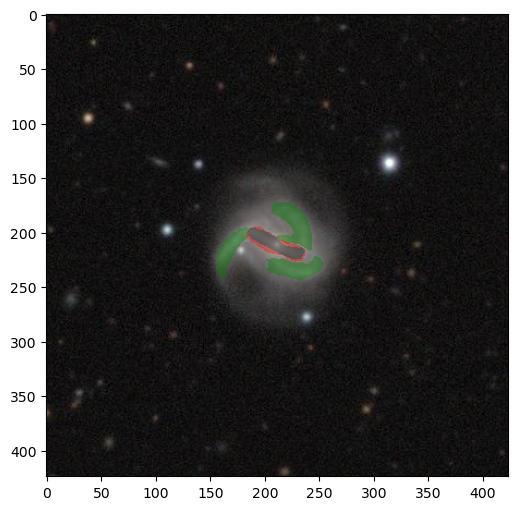

In [97]:
score_threshold = 0.3
mask_threshold = 0.7

objid = 335470782

image = decode_image(IMAGE_DATA_PATH + 'mask_train_images_pngs/' + str(objid) + '.png')
eval_transform = get_transform(train=False)

with torch.no_grad():
    x = eval_transform(image)
    # convert RGBA -> RGB and move to device
    x = x[:3, ...].to(TORCH_DEVICE)
    predictions = mask_rcnn_model([x, ])
    pred = predictions[0]

image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]

pred_labels = [f"{label}: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])]
pred_boxes = pred["boxes"].long()

idx = set((pred['scores'] >= score_threshold).nonzero().flatten().tolist())
idx_spiral = list(set((pred['labels'] == 1).nonzero().flatten().tolist()).intersection(idx))
idx_bar = list(set((pred['labels'] == 2).nonzero().flatten().tolist()).intersection(idx))

masks_spiral = (pred['masks'][idx_spiral] > mask_threshold).squeeze(1)
masks_bars = (pred['masks'][idx_bar] > mask_threshold).squeeze(1)

output_image = draw_segmentation_masks(image, masks_spiral, alpha=0.4, colors='green')
output_image = draw_segmentation_masks(output_image, masks_bars, alpha=0.4, colors='red') 

# output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors='red', width=1)

plt.figure(figsize=(6, 6))
plt.imshow(output_image.permute(1, 2, 0))

In [75]:
pred_labels

['2: 0.999', '1: 0.998', '2: 0.497', '2: 0.249', '1: 0.073']